In [106]:
# Installazione delle librerie Python necessarie per il progetto
%pip install kagglehub matplotlib scikit-learn pandas keras numpy tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Analisi Dataset

Import delle librerie necessarie alla sezione

In [107]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

Setup iniziale per la creazione della directory dove salvare le visualizzazioni generate durante l'analisi.

In [108]:
# Crea la cartella per salvare i grafici generati
os.makedirs("images", exist_ok=True)

Caricamento del dataset dal repository UCI e preparazione del DataFrame per l'analisi esplorativa.

In [109]:
# Download latest version
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

# Utilizza il dataset cardio_train.csv
df = pd.read_csv(os.path.join(path, "cardio_train.csv"), sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Adattamento delle feature a misure standard

In [110]:
df["gender"] = df["gender"] - 1  # Converti il gender da 1,2 a 0,1
df["height"] = df["height"] / 100  # Converti altezza da cm a m
df["age"] = df["age"] / 365.25  # Converti età da giorni a anni
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.357290,1,1.68,62.0,110,80,1,1,0,0,1,0
1,1,55.381246,0,1.56,85.0,140,90,3,1,0,0,1,1
2,2,51.627652,0,1.65,64.0,130,70,3,1,0,0,0,1
3,3,48.249144,1,1.69,82.0,150,100,1,1,0,0,1,1
4,4,47.841205,0,1.56,56.0,100,60,1,1,0,0,0,0


Analisi preliminare dei tipi di dati

In [111]:
# Mostra i tipi di dato di ciascuna feature
df.dtypes

id               int64
age            float64
gender           int64
height         float64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

### Gestione delle Feature

In [112]:
# Rimuove ID (non predittivo)
df = df.drop(columns=["id"]).copy()

# Definizione dei tipi di feature
numeric_features = ["age", "height", "weight", "ap_hi", "ap_lo"]
binary_features = ["gender", "smoke", "alco", "active"]
ordinal_features = ["cholesterol", "gluc"]

print(f"Feature numeriche: {numeric_features}")
print(f"Feature binarie: {binary_features}")
print(f"Feature ordinali: {ordinal_features}")

Feature numeriche: ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
Feature binarie: ['gender', 'smoke', 'alco', 'active']
Feature ordinali: ['cholesterol', 'gluc']


In [113]:
# Converte binary_features e ordinal_features in tipo 'category'
for col in binary_features + ordinal_features:
    df[col] = df[col].astype("category")

print(df.dtypes)

age             float64
gender         category
height          float64
weight          float64
ap_hi             int64
ap_lo             int64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio            int64
dtype: object


## Analisi Esplorativa

### Statistiche Descrittive

In [114]:
df[numeric_features].describe()

,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,53.302850,1.643592,74.205690,128.817286,96.630414
std,6.754967,0.082101,14.395757,154.011419,188.472530
min,29.563313,0.550000,10.000000,-150.000000,-70.000000
25%,48.361396,1.590000,65.000000,120.000000,80.000000
50%,53.943874,1.650000,72.000000,120.000000,80.000000
75%,58.390144,1.700000,82.000000,140.000000,90.000000
max,64.922656,2.500000,200.000000,16020.000000,11000.000000


### Rimozione Outliers

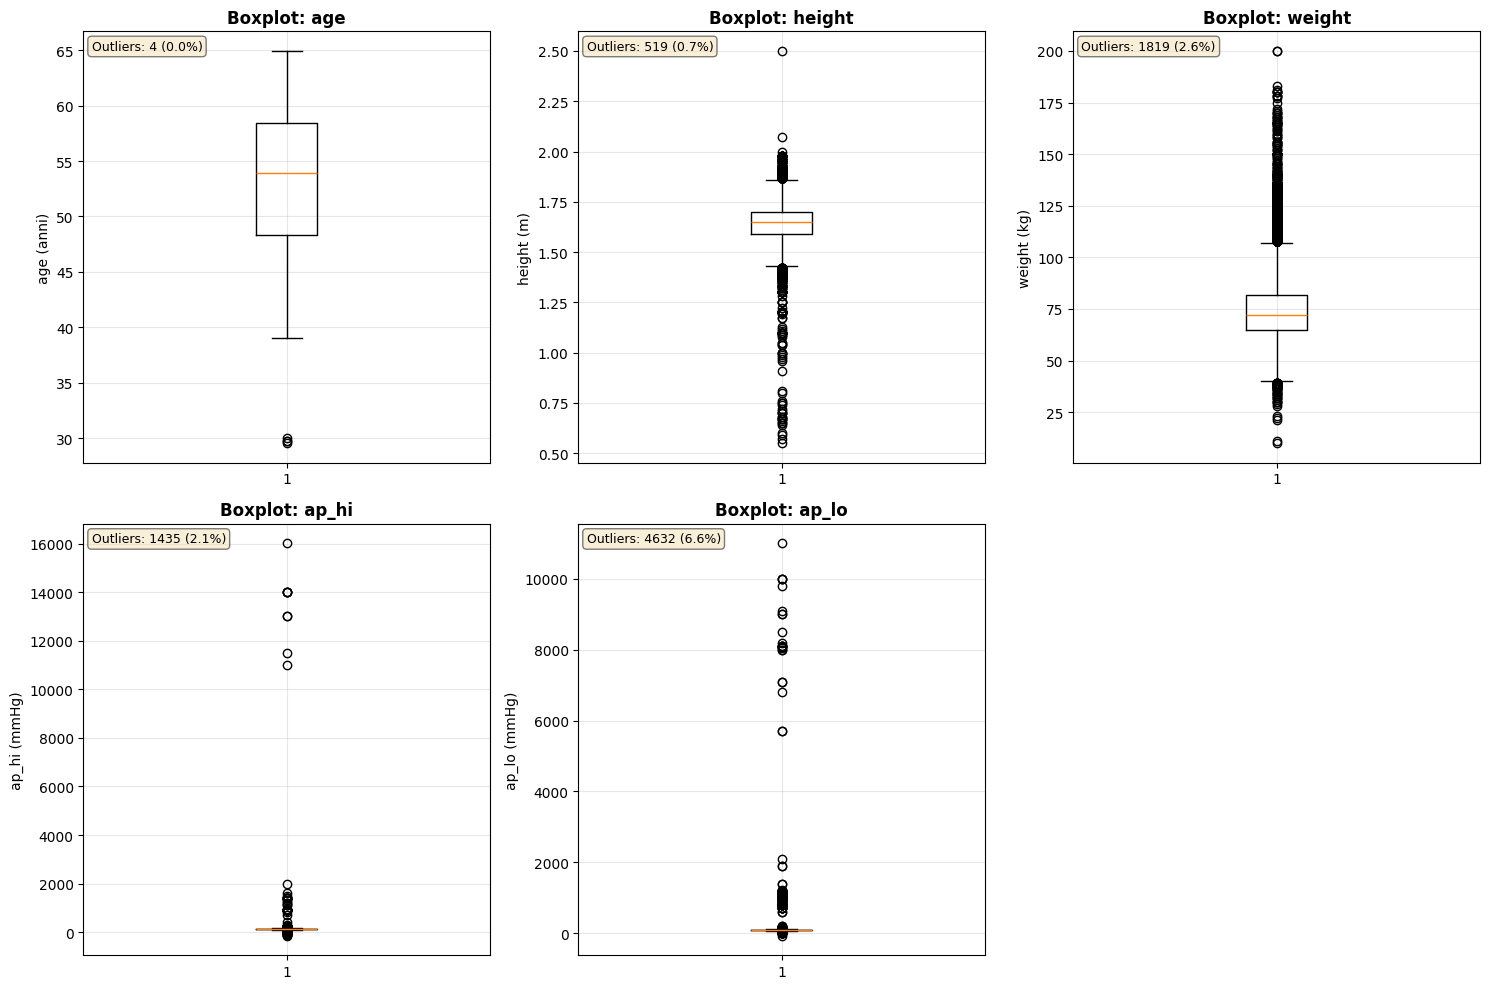


Dataset prima della rimozione outliers: (70000, 12)


In [115]:
# Visualizza distribuzione delle features numeriche prima della rimozione outliers
units = {"age": "anni", "height": "m", "weight": "kg", "ap_hi": "mmHg", "ap_lo": "mmHg"}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f"Boxplot: {col}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel(f"{col} ({units[col]})", fontsize=10)
    axes[idx].grid(True, alpha=0.3)

    # Calcola statistiche IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Aggiungi info statistiche
    axes[idx].text(
        0.02,
        0.98,
        f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)",
        transform=axes[idx].transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/boxplots_before_cleaning.svg", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nDataset prima della rimozione outliers: {df.shape}")

#### Pressione Sanguigna

In [116]:
# Pulisci il dataset rimuovendo record con valori fisiologicamente impossibili
print(f"Istanze prima della pulizia: {len(df)}")

# Limiti fisiologici realistici per la pressione sanguigna
df_clean = df[
    (df["ap_hi"] > 50)
    & (df["ap_hi"] <= 250)
    & (df["ap_lo"] > 30)
    & (df["ap_lo"] <= 200)
    & (df["ap_hi"] > df["ap_lo"])
].copy()

print(f"Istanze dopo la pulizia: {len(df_clean)}")
print(
    f"Record rimossi: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)"
)

# Aggiorna il dataframe principale
df = df_clean.copy()

Istanze prima della pulizia: 70000
Istanze dopo la pulizia: 68672
Record rimossi: 1328 (1.90%)


#### Altezza e Peso

In [117]:
# Rimuove outliers per altezza (sotto 2.5% o sopra 97.5%)
height_lower = df["height"].quantile(0.025)
height_upper = df["height"].quantile(0.975)
df = df[(df["height"] >= height_lower) & (df["height"] <= height_upper)]

# Rimuove outliers per peso (sotto 2.5% o sopra 97.5%)
weight_lower = df["weight"].quantile(0.025)
weight_upper = df["weight"].quantile(0.975)
df = df[(df["weight"] >= weight_lower) & (df["weight"] <= weight_upper)]

print(f"Dataset dopo rimozione outliers altezza/peso: {df.shape}")

Dataset dopo rimozione outliers altezza/peso: (62701, 12)


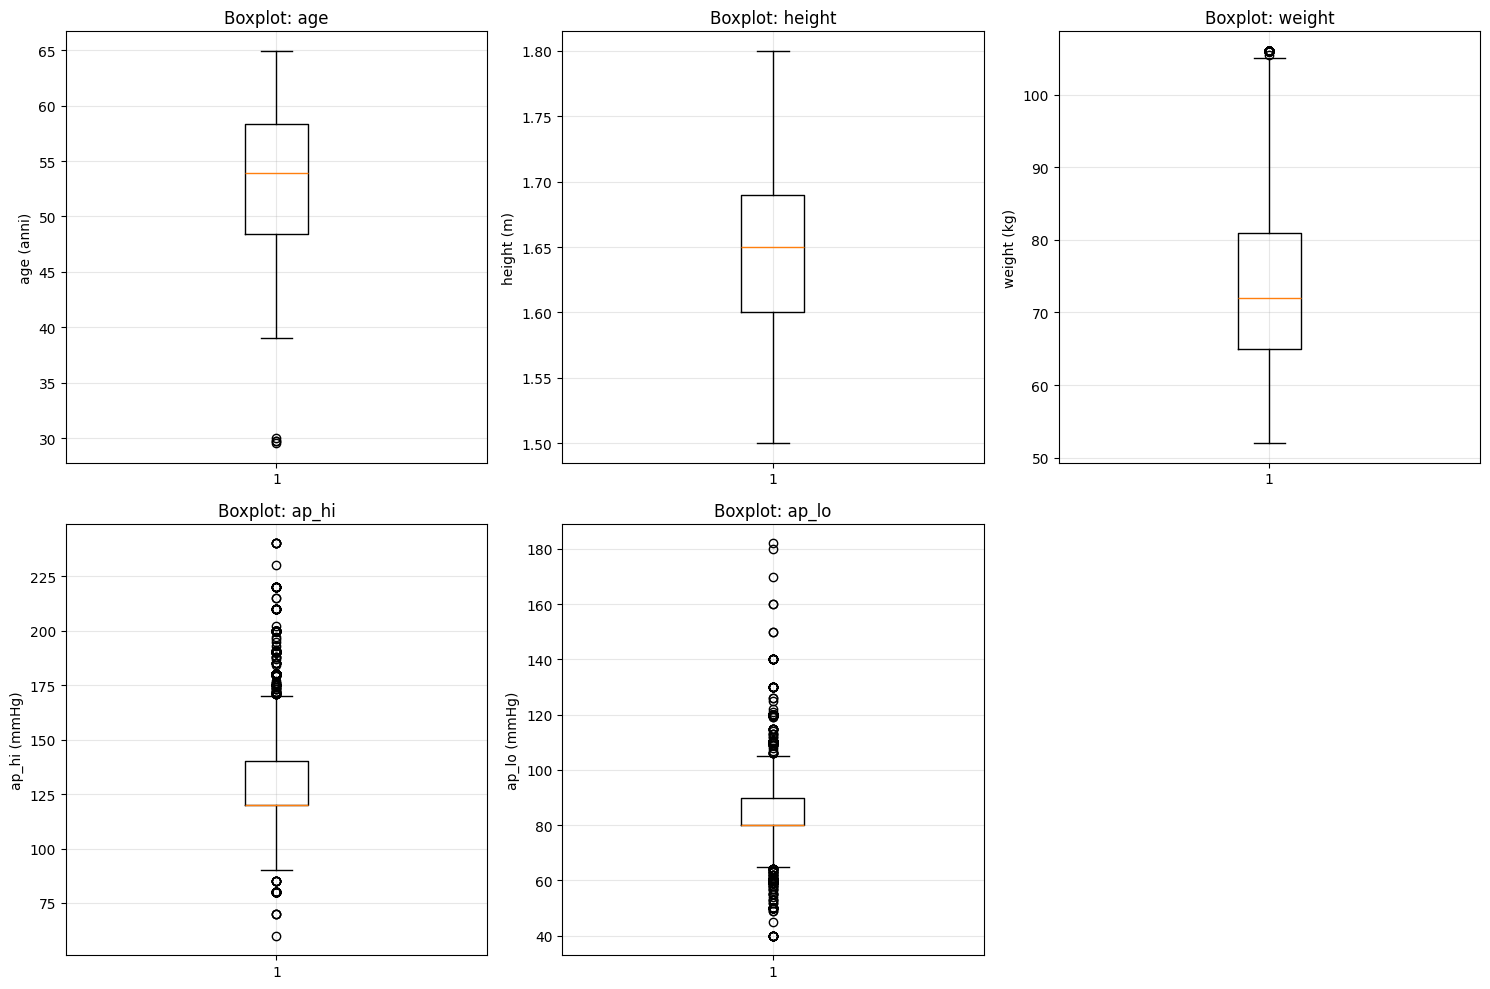

In [118]:
# Visualizza distribuzione delle features numeriche dopo la rimozione degli outliers
units = {"age": "anni", "height": "m", "weight": "kg", "ap_hi": "mmHg", "ap_lo": "mmHg"}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f"Boxplot: {col}")
    axes[idx].set_ylabel(f"{col} ({units[col]})")
    axes[idx].grid(True, alpha=0.3)

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/outliers_boxplots_cleaned.svg", format="svg", bbox_inches="tight")
plt.show()

### Analisi Correlazioni

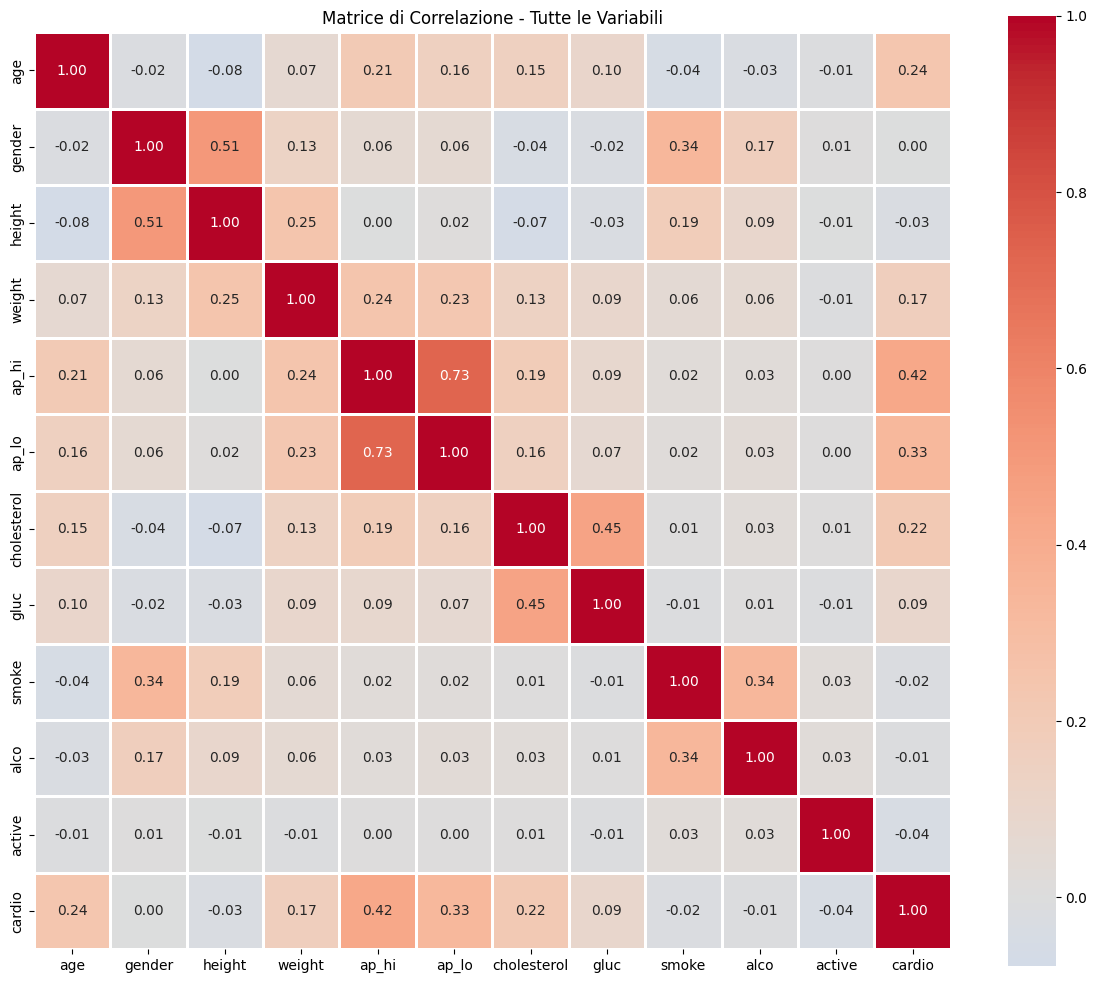


Correlazione con la variabile target (cardio):
cardio         1.000000
ap_hi          0.424727
ap_lo          0.333371
age            0.240174
cholesterol    0.218010
weight         0.166916
gluc           0.087257
gender         0.001738
alco          -0.011659
smoke         -0.020585
height        -0.025805
active        -0.037021
Name: cardio, dtype: float64


In [119]:
# Calcola la matrice di correlazione
correlation_matrix = df.corr()

# Visualizza la matrice di correlazione con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
)
plt.title("Matrice di Correlazione - Tutte le Variabili")
plt.tight_layout()
plt.savefig("images/correlation_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

# Mostra le correlazioni con la variabile target (cardio) in ordine decrescente
print("\nCorrelazione con la variabile target (cardio):")
target_corr = correlation_matrix["cardio"].sort_values(ascending=False)
print(target_corr)

### Distribuzioni

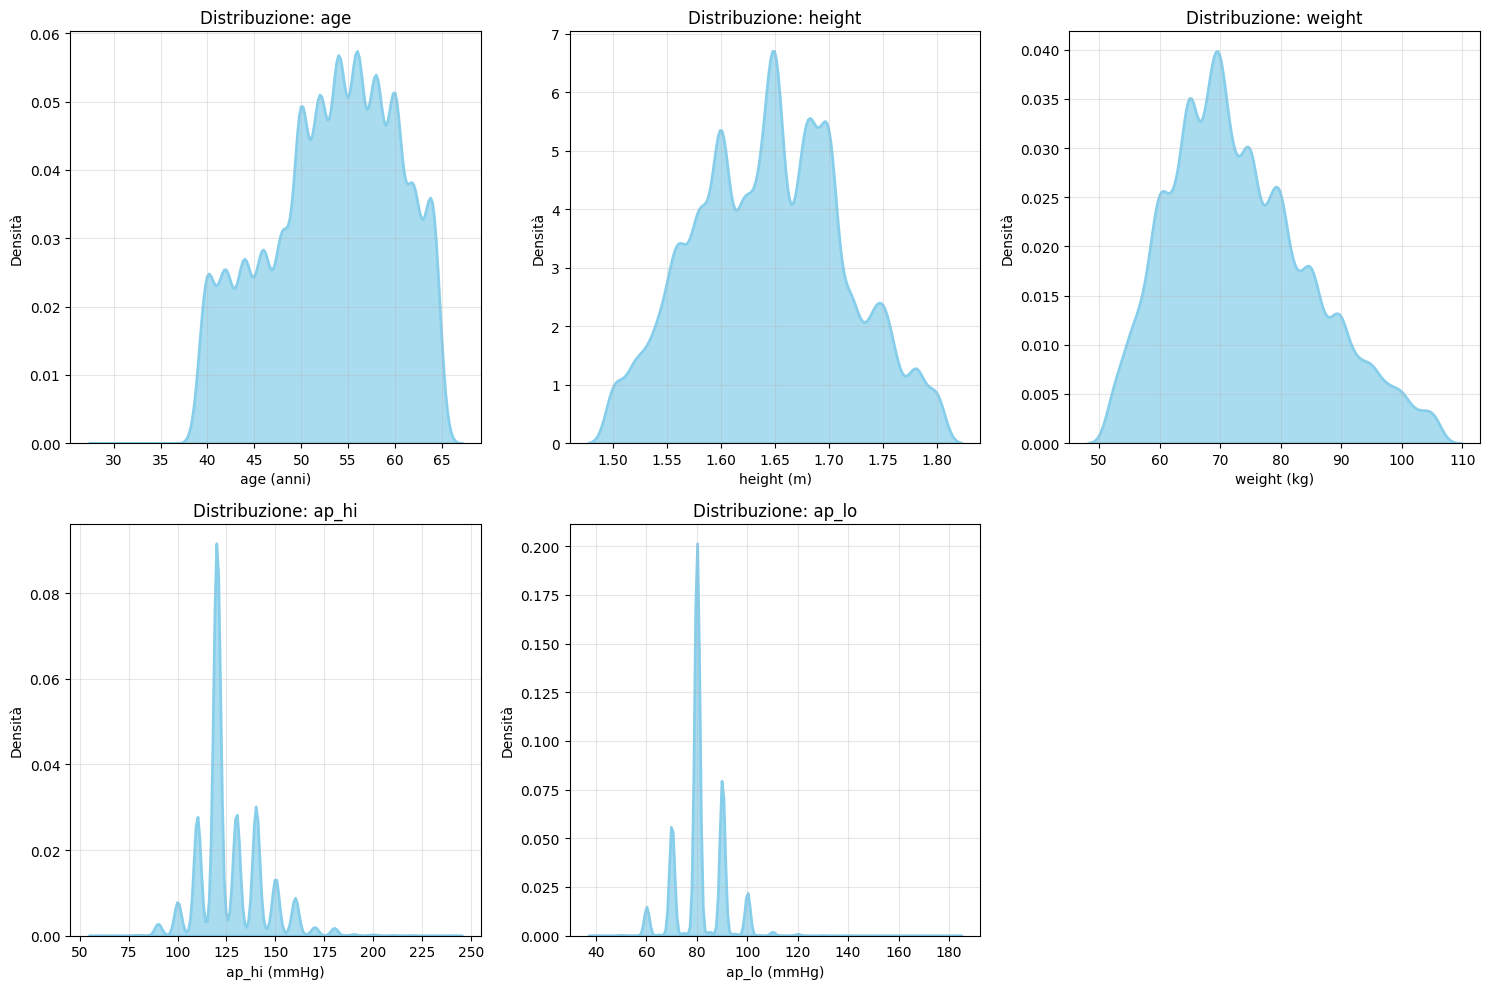

In [120]:
# Curve di densità per le feature numeriche
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    # Usa dati convertiti per visualizzazione
    data = df[col].dropna()

    # Sostituzione istogramma con KDE plot
    sns.kdeplot(
        data,
        ax=axes[idx],
        fill=True,  # Colora l'area sotto la curva
        color="skyblue",
        alpha=0.7,
        linewidth=2,
    )

    axes[idx].set_title(f"Distribuzione: {col}")
    axes[idx].set_xlabel(f"{col} ({units[col]})")
    axes[idx].set_ylabel("Densità")  # Cambiato da Frequenza a Densità
    axes[idx].grid(True, alpha=0.3)

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/distributions_curves.svg", format="svg", bbox_inches="tight")
plt.show()

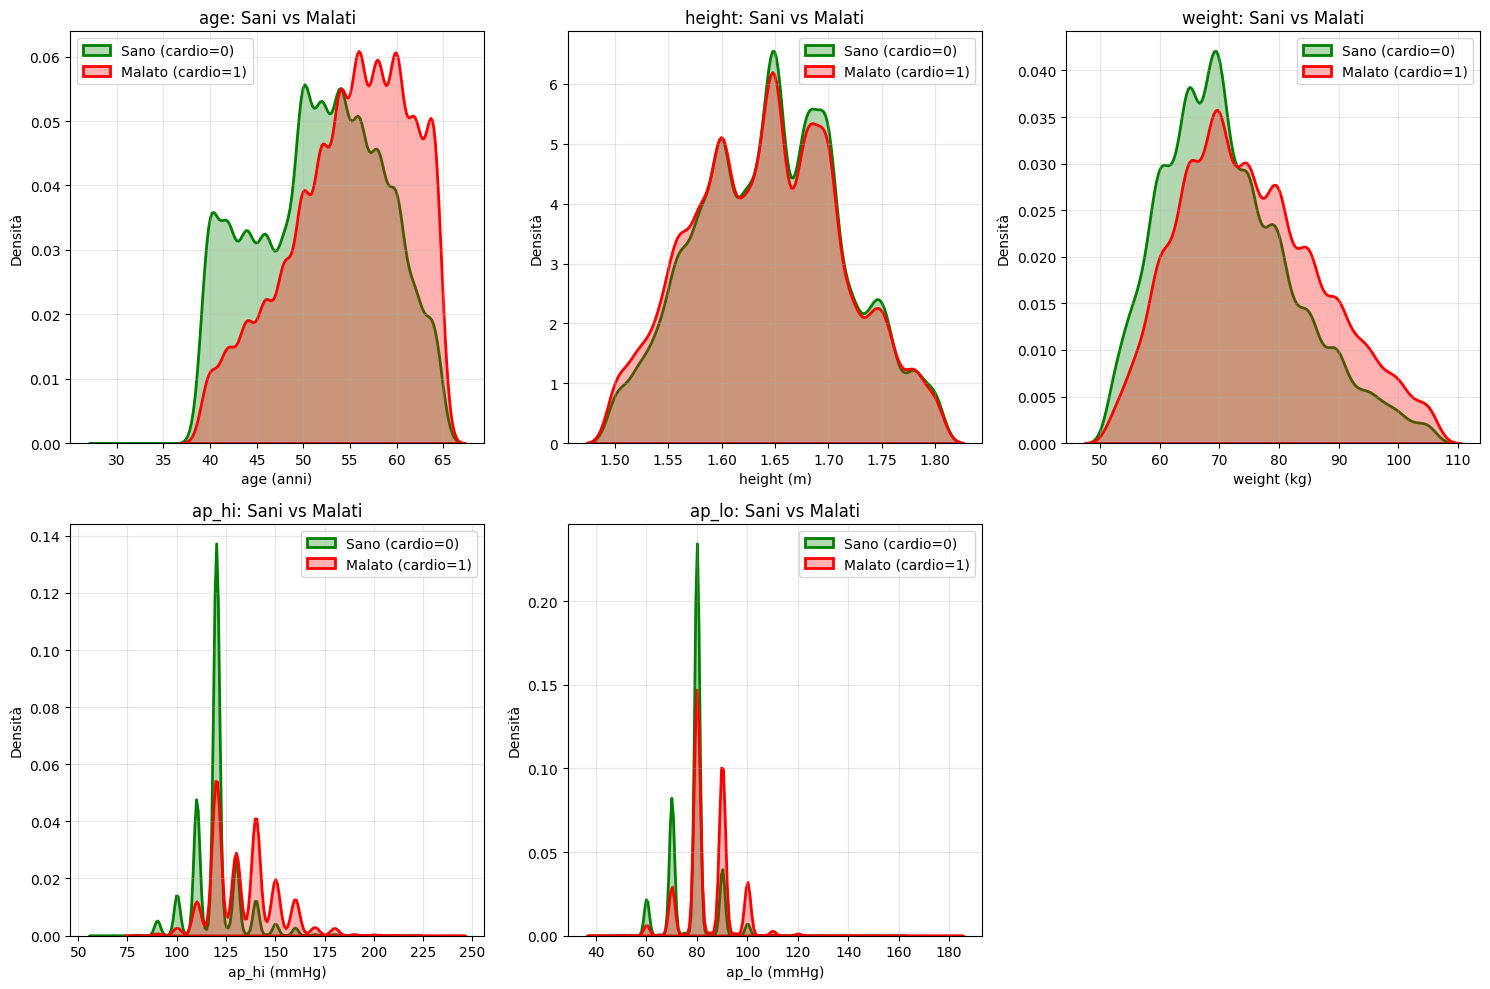

In [121]:
# Confronto densità tra pazienti sani (cardio=0) e malati (cardio=1)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    # Separa i dati per target (usa dati convertiti)
    healthy = df[df["cardio"] == 0][col].dropna()
    sick = df[df["cardio"] == 1][col].dropna()

    # Plot Sani (Verde)
    sns.kdeplot(
        healthy,
        ax=axes[idx],
        fill=True,
        label="Sano (cardio=0)",
        color="green",
        alpha=0.3,  # Più trasparente per vedere la sovrapposizione
        linewidth=2,
    )

    # Plot Malati (Rosso)
    sns.kdeplot(
        sick,
        ax=axes[idx],
        fill=True,
        label="Malato (cardio=1)",
        color="red",
        alpha=0.3,
        linewidth=2,
    )

    axes[idx].set_title(f"{col}: Sani vs Malati")
    axes[idx].set_xlabel(f"{col} ({units[col]})")
    axes[idx].set_ylabel("Densità")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig(
    "images/distributions_comparison_curves.svg", format="svg", bbox_inches="tight"
)
plt.show()

## Preparazione Features

Dopo la pulizia del dataset, ridefinisce le features e il target usando il dataframe pulito.

In [122]:
# Ridefinisce features e target dal dataframe pulito
features = df.drop(columns=["cardio"]).copy()
y = df["cardio"].values

print(f"Features shape: {features.shape}")
print(f"Target shape: {y.shape}")
print(features.dtypes)

Features shape: (62701, 11)
Target shape: (62701,)
age             float64
gender         category
height          float64
weight          float64
ap_hi             int64
ap_lo             int64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
dtype: object


In [123]:
# Applica One-Hot Encoding alle feature ordinali per le reti neurali
features_nn = pd.get_dummies(
    features, columns=ordinal_features, drop_first=False, dtype=int
)

# Identifica le colonne One-Hot generate
onehot_cols = [
    col for col in features_nn.columns if col not in numeric_features + binary_features
]

# Lista completa delle feature per NN
all_features_nn = numeric_features + binary_features + onehot_cols
FEATURES_NUMBER_NN = len(all_features_nn)

print(f"\nDataset per Reti Neurali:")
print(f"  Dimensioni: {features_nn.shape}")
print(f"  Feature totali: {FEATURES_NUMBER_NN}")
print(f"  - {len(numeric_features)} numeriche")
print(f"  - {len(binary_features)} binarie")
print(f"  - {len(onehot_cols)} One-Hot encoded")
print(f"\nColonne One-Hot: {onehot_cols}")


Dataset per Reti Neurali:
  Dimensioni: (62701, 15)
  Feature totali: 15
  - 5 numeriche
  - 4 binarie
  - 6 One-Hot encoded

Colonne One-Hot: ['cholesterol_1', 'cholesterol_2', 'cholesterol_3', 'gluc_1', 'gluc_2', 'gluc_3']


In [124]:
# Mantieni le feature ordinali come interi per Decision Tree
features_dt = features.copy()

# Converte le ordinali da category a int per interpretabilità
for col in ordinal_features:
    features_dt[col] = features_dt[col].astype(int)

# Lista completa delle feature per DT
all_features_dt = numeric_features + binary_features + ordinal_features
FEATURES_NUMBER_DT = len(all_features_dt)

# Prepara array per DT (NON SCALATO)
X_dt = features_dt[all_features_dt].values

print(f"\nDataset per Decision Tree:")
print(f"  Dimensioni: {X_dt.shape}")
print(f"  Feature totali: {FEATURES_NUMBER_DT}")
print(f"  - {len(numeric_features)} numeriche")
print(f"  - {len(binary_features)} binarie")
print(f"  - {len(ordinal_features)} ordinali (come interi)")
print(f"\nFeature ordinali come interi: {ordinal_features}")


Dataset per Decision Tree:
  Dimensioni: (62701, 11)
  Feature totali: 11
  - 5 numeriche
  - 4 binarie
  - 2 ordinali (come interi)

Feature ordinali come interi: ['cholesterol', 'gluc']


## Preparazione Dati

In [125]:
# Scala solo le feature numeriche
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(features_nn[numeric_features])

# Mantieni binarie e One-Hot inalterate (0/1)
binary_onehot_data = features_nn[binary_features + onehot_cols].values

# Concatena le feature scalate e non scalate
X_nn = np.concatenate([numeric_scaled, binary_onehot_data], axis=1)

print(f"Dati per Reti Neurali - Shape: {X_nn.shape}")

Dati per Reti Neurali - Shape: (62701, 15)


In [126]:
# Calcola la distribuzione percentuale delle classi
class_distribution = df["cardio"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
cardio
0    50.654695
1    49.345305
Name: proportion, dtype: float64


## Splitting del Dataset

Suddivisione del dataset in training set (70%) e test set (30%) per entrambi gli approcci (NN e DT).

### Reti Neurali

In [127]:
# Split per Reti Neurali (dati scalati con One-Hot)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y, test_size=0.3, random_state=42
)

print(f"Split Reti Neurali:")
print(f"  Training: {X_train_nn.shape}, Test: {X_test_nn.shape}")

Split Reti Neurali:
  Training: (43890, 15), Test: (18811, 15)


### Decision Tree

In [128]:
# Split per Decision Tree (dati NON scalati, ordinali come interi)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y, test_size=0.3, random_state=42
)


print(f"\nSplit Decision Tree:")
print(f"  Training: {X_train_dt.shape}, Test: {X_test_dt.shape}")


Split Decision Tree:
  Training: (43890, 11), Test: (18811, 11)


# Reti Neurali

Importazione delle librerie necessarie per la creazione e il training delle reti neurali.

In [129]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.metrics import F1Score
from sklearn.utils import class_weight
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV

Funzione di valutazione completa per analizzare le performance dei modelli di rete neurale.

In [130]:
# Valuta e visualizza le performance di un modello di rete neurale
def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Predice probabilità e applica threshold
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Calcola e visualizza matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa metriche di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcola curva ROC e AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    # Baseline random classifier
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_roc_curve_{file_suffix}.svg", format="svg", bbox_inches="tight"
    )
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Visualizza loss e accuracy durante training
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"images/nn_training_curves_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

## Standard Dataset

Creazione e training di una rete neurale con architettura sequenziale su dataset standard non bilanciato.

In [131]:
# Crea modello sequenziale con 2 layer nascosti
model = Sequential()

# Layer nascosti: 64 -> 32 neuroni con ReLU e Dropout
model.add(Input(shape=(FEATURES_NUMBER_NN,)))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(32, activation="relu"))
model.add(Dropout(0.3))

# Layer output con sigmoid per classificazione binaria
model.add(Dense(1, activation="sigmoid"))

# Stategia early stopping per prevenire overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

# Compila con binary crossentropy e Adam optimizer
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# Training con 150 epoche, batch size 256 e validation split 10%
history = model.fit(
    X_train_nn,
    y_train_nn,
    epochs=300,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    callbacks=[early_stopping],
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6853 - loss: 0.5998 - val_accuracy: 0.7334 - val_loss: 0.5523
Epoch 2/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7193 - loss: 0.5722 - val_accuracy: 0.7352 - val_loss: 0.5484
Epoch 3/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7217 - loss: 0.5653 - val_accuracy: 0.7382 - val_loss: 0.5457
Epoch 4/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7244 - loss: 0.5631 - val_accuracy: 0.7375 - val_loss: 0.5439
Epoch 5/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7283 - loss: 0.5600 - val_accuracy: 0.7368 - val_loss: 0.5452
Epoch 6/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7274 - loss: 0.5583 - val_accuracy: 0.7375 - val_loss: 0.5439
Epoch 7/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.5574 - val_accuracy: 0.7389 - val_loss: 0.5425
Epoch 8/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7291 - loss: 0.5564 - val_accu

### Risultati e Metriche

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 805us/step


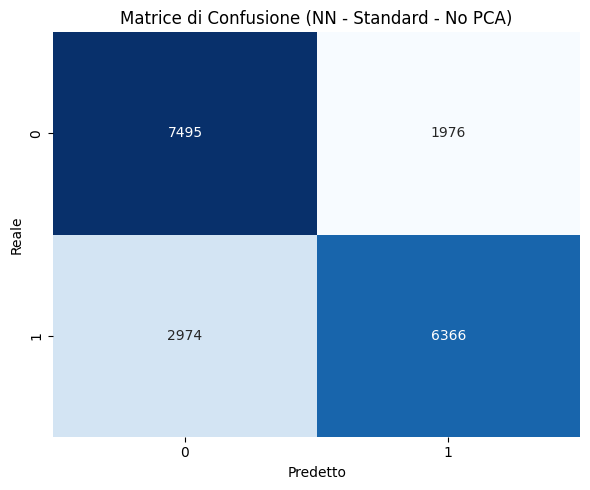

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      9471
           1       0.76      0.68      0.72      9340

    accuracy                           0.74     18811
   macro avg       0.74      0.74      0.74     18811
weighted avg       0.74      0.74      0.74     18811



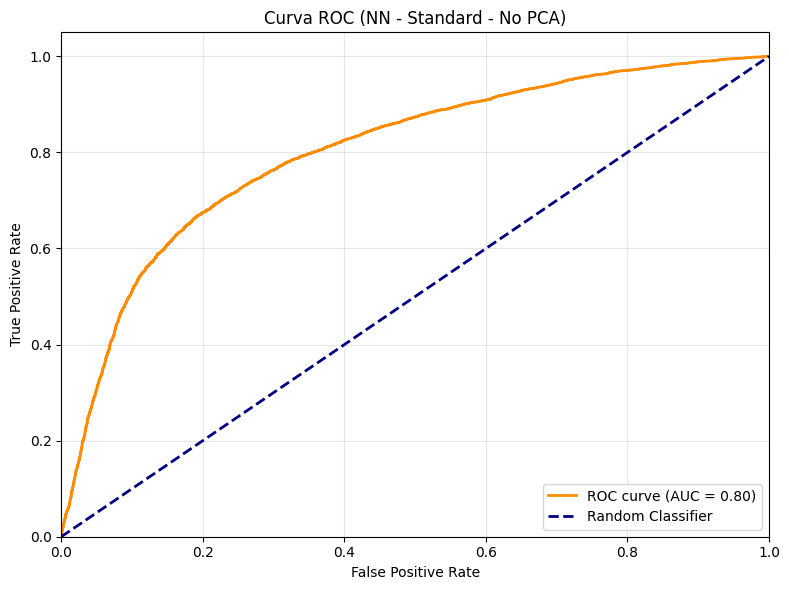


AUC Score: 0.8017


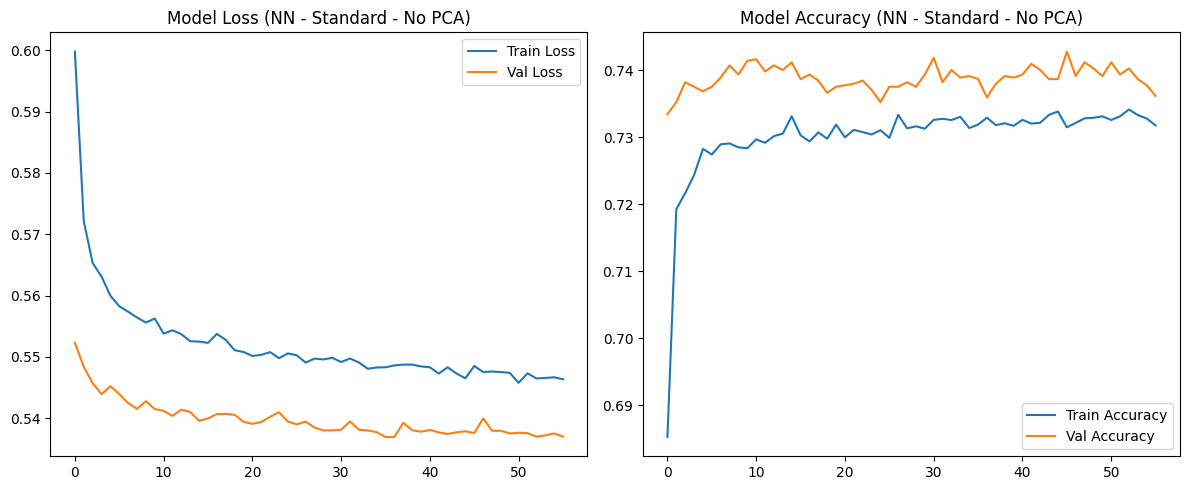

In [132]:
# Valuta il modello e genera grafici delle metriche
evaluate_and_plot(
    model, X_test_nn, y_test_nn, history, title_suffix="NN - Standard - No PCA"
)

## Class Weight

Rete neurale addestrata con pesi di classe bilanciati per gestire lo sbilanciamento durante il training.

In [133]:
# Calcola pesi bilanciati per le classi
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_nn), y=y_train_nn
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# Architettura: 128 -> 64 -> 32
model_class_weights = Sequential()

model_class_weights.add(Input(shape=(FEATURES_NUMBER_NN,)))

model_class_weights.add(Dense(64, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(32, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(1, activation="sigmoid"))

# Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

model_class_weights.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# Training con class_weight - 100 epochs
history_class_weights = model_class_weights.fit(
    X_train_nn,
    y_train_nn,
    epochs=300,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
    callbacks=[early_stopping],
)

Pesi delle classi: {0: np.float64(0.9845222072678331), 1: np.float64(1.0159722222222223)}
Epoch 1/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6939 - loss: 0.5948 - val_accuracy: 0.7311 - val_loss: 0.5535
Epoch 2/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7183 - loss: 0.5702 - val_accuracy: 0.7350 - val_loss: 0.5493
Epoch 3/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7221 - loss: 0.5647 - val_accuracy: 0.7398 - val_loss: 0.5462
Epoch 4/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7239 - loss: 0.5614 - val_accuracy: 0.7380 - val_loss: 0.5457
Epoch 5/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7252 - loss: 0.5599 - val_accuracy: 0.7407 - val_loss: 0.5448
Epoch 6/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7264 - loss: 0.5589 - val_accuracy: 0.7398 - val_loss: 0.5435
Epoch 7/300
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7273 - loss: 0.5583 - val_accuracy: 0.7389 - val_loss: 0.5444
Epoch 8

### Risultati e Metriche

588/588 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step


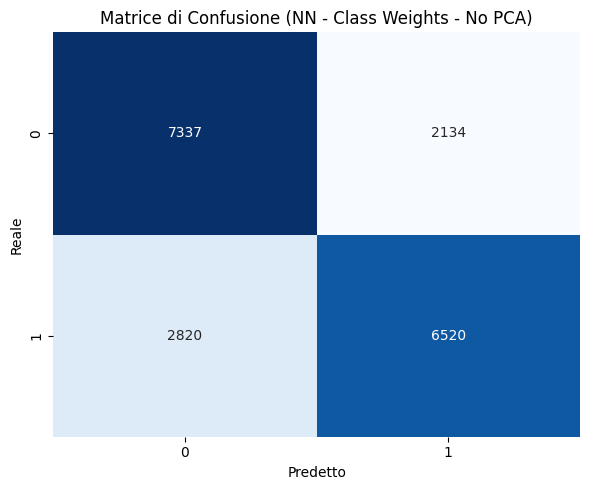

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.72      0.77      0.75      9471
           1       0.75      0.70      0.72      9340

    accuracy                           0.74     18811
   macro avg       0.74      0.74      0.74     18811
weighted avg       0.74      0.74      0.74     18811



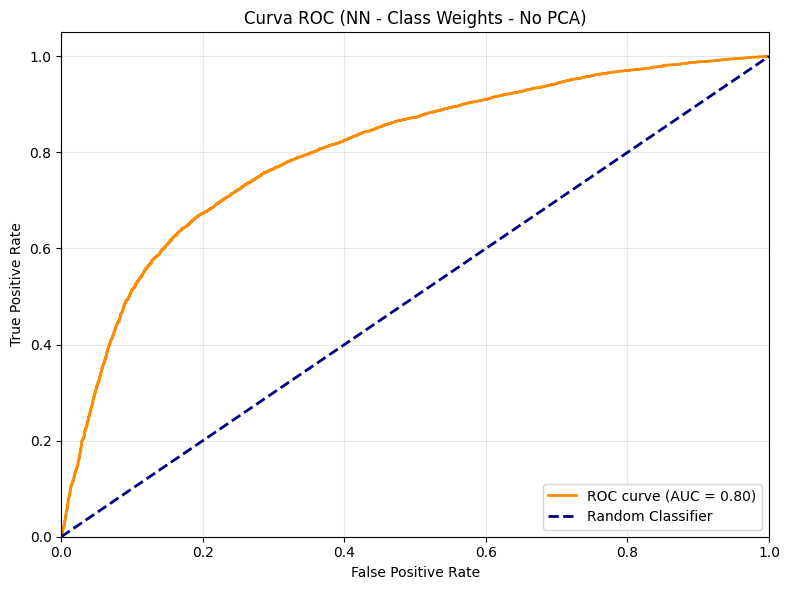


AUC Score: 0.8022


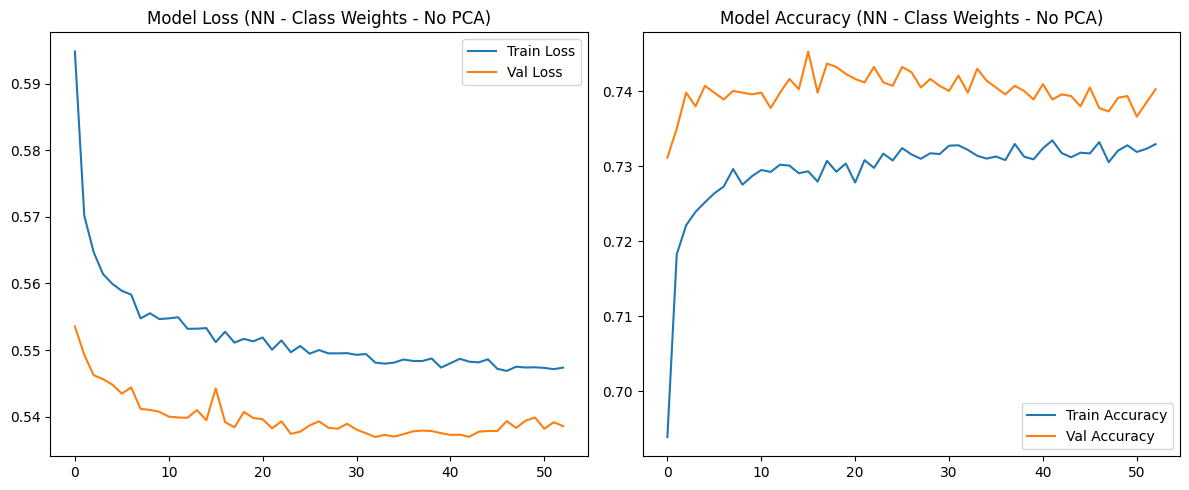

In [134]:
# Valuta modello con class weights
evaluate_and_plot(
    model_class_weights,
    X_test_nn,
    y_test_nn,
    history_class_weights,
    threshold=0.5,
    title_suffix="NN - Class Weights - No PCA",
)

# Alberi di Decisione

Definizione delle funzioni di supporto per visualizzazione e valutazione degli alberi di decisione.

In [135]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, DecisionTreeClassifier
import pandas as pd


# Calcola e visualizza le metriche di performance dell'albero
def show_tree_metrics(tree, y_test, y_pred, title_suffix):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Caratteristiche strutturali albero
    if hasattr(tree, "get_depth"):
        print(f"Profondità albero: {tree.get_depth()}")
        print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/dt_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


# Visualizza la struttura dell'albero di decisione
def print_tree(tree, max_depth, title, feature_names):
    file_suffix = (
        title.lower().replace(" ", "_").replace("-", "") if title else "decision_tree"
    )
    plt.figure(figsize=(50, 24))

    # Genera grafico albero con nodi colorati
    plot_tree(
        tree,
        filled=True,
        feature_names=feature_names,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/dt_{file_suffix}.svg", format="svg", bbox_inches="tight")
    plt.show()

Funzione per analizzare e visualizzare l'importanza delle feature nell'albero di decisione.

In [136]:
# Visualizza l'importanza delle feature nell'albero
def plot_feature_importance(tree, feature_names, title_suffix, top_n=None):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Estrae feature importance dall'albero
    importances = tree.feature_importances_

    # Crea DataFrame e ordina per importanza
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    # Limita alle top_n feature
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Crea grafico a barre orizzontali
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importance_df)), importance_df["importance"])
    plt.yticks(range(len(importance_df)), importance_df["feature"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    title = "Feature Importance" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(
        f"images/dt_feature_importance_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa valori
    print(f"\nFeature Importance{' (' + title_suffix + ')' if title_suffix else ''}:")
    print(importance_df.to_string(index=False))

Funzione per eseguire Grid Search con cross-validation per trovare i migliori iperparametri.

In [137]:
# Esegue Grid Search per trovare i migliori iperparametri
def run_grid_search(
    X_train, y_train, param_grid, class_weight="balanced", cv=5, scoring="f1"
):
    base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight)

    # Inizializza Grid Search con cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{'='*60}")
    print(f"RISULTATI GRID SEARCH (scoring={scoring}, cv={cv})")
    print(f"{'='*60}")
    print(f"Migliori parametri: {grid_search.best_params_}")
    print(f"Miglior score ({scoring}): {grid_search.best_score_:.4f}")
    print(f"{'='*60}\n")

    return grid_search.best_estimator_, grid_search

Definizione della griglia di iperparametri da testare con Grid Search.

In [138]:
# Griglia iperparametri per Grid Search
dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

## Standard Dataset

In [139]:
# Esegue Grid Search senza class weights sui dati non scalati
dt_standard, grid_search_standard = run_grid_search(
    X_train_dt, y_train_dt, dt_param_grid, class_weight=None
)
y_pred_standard = dt_standard.predict(X_test_dt)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7199



### Risultati e Metriche

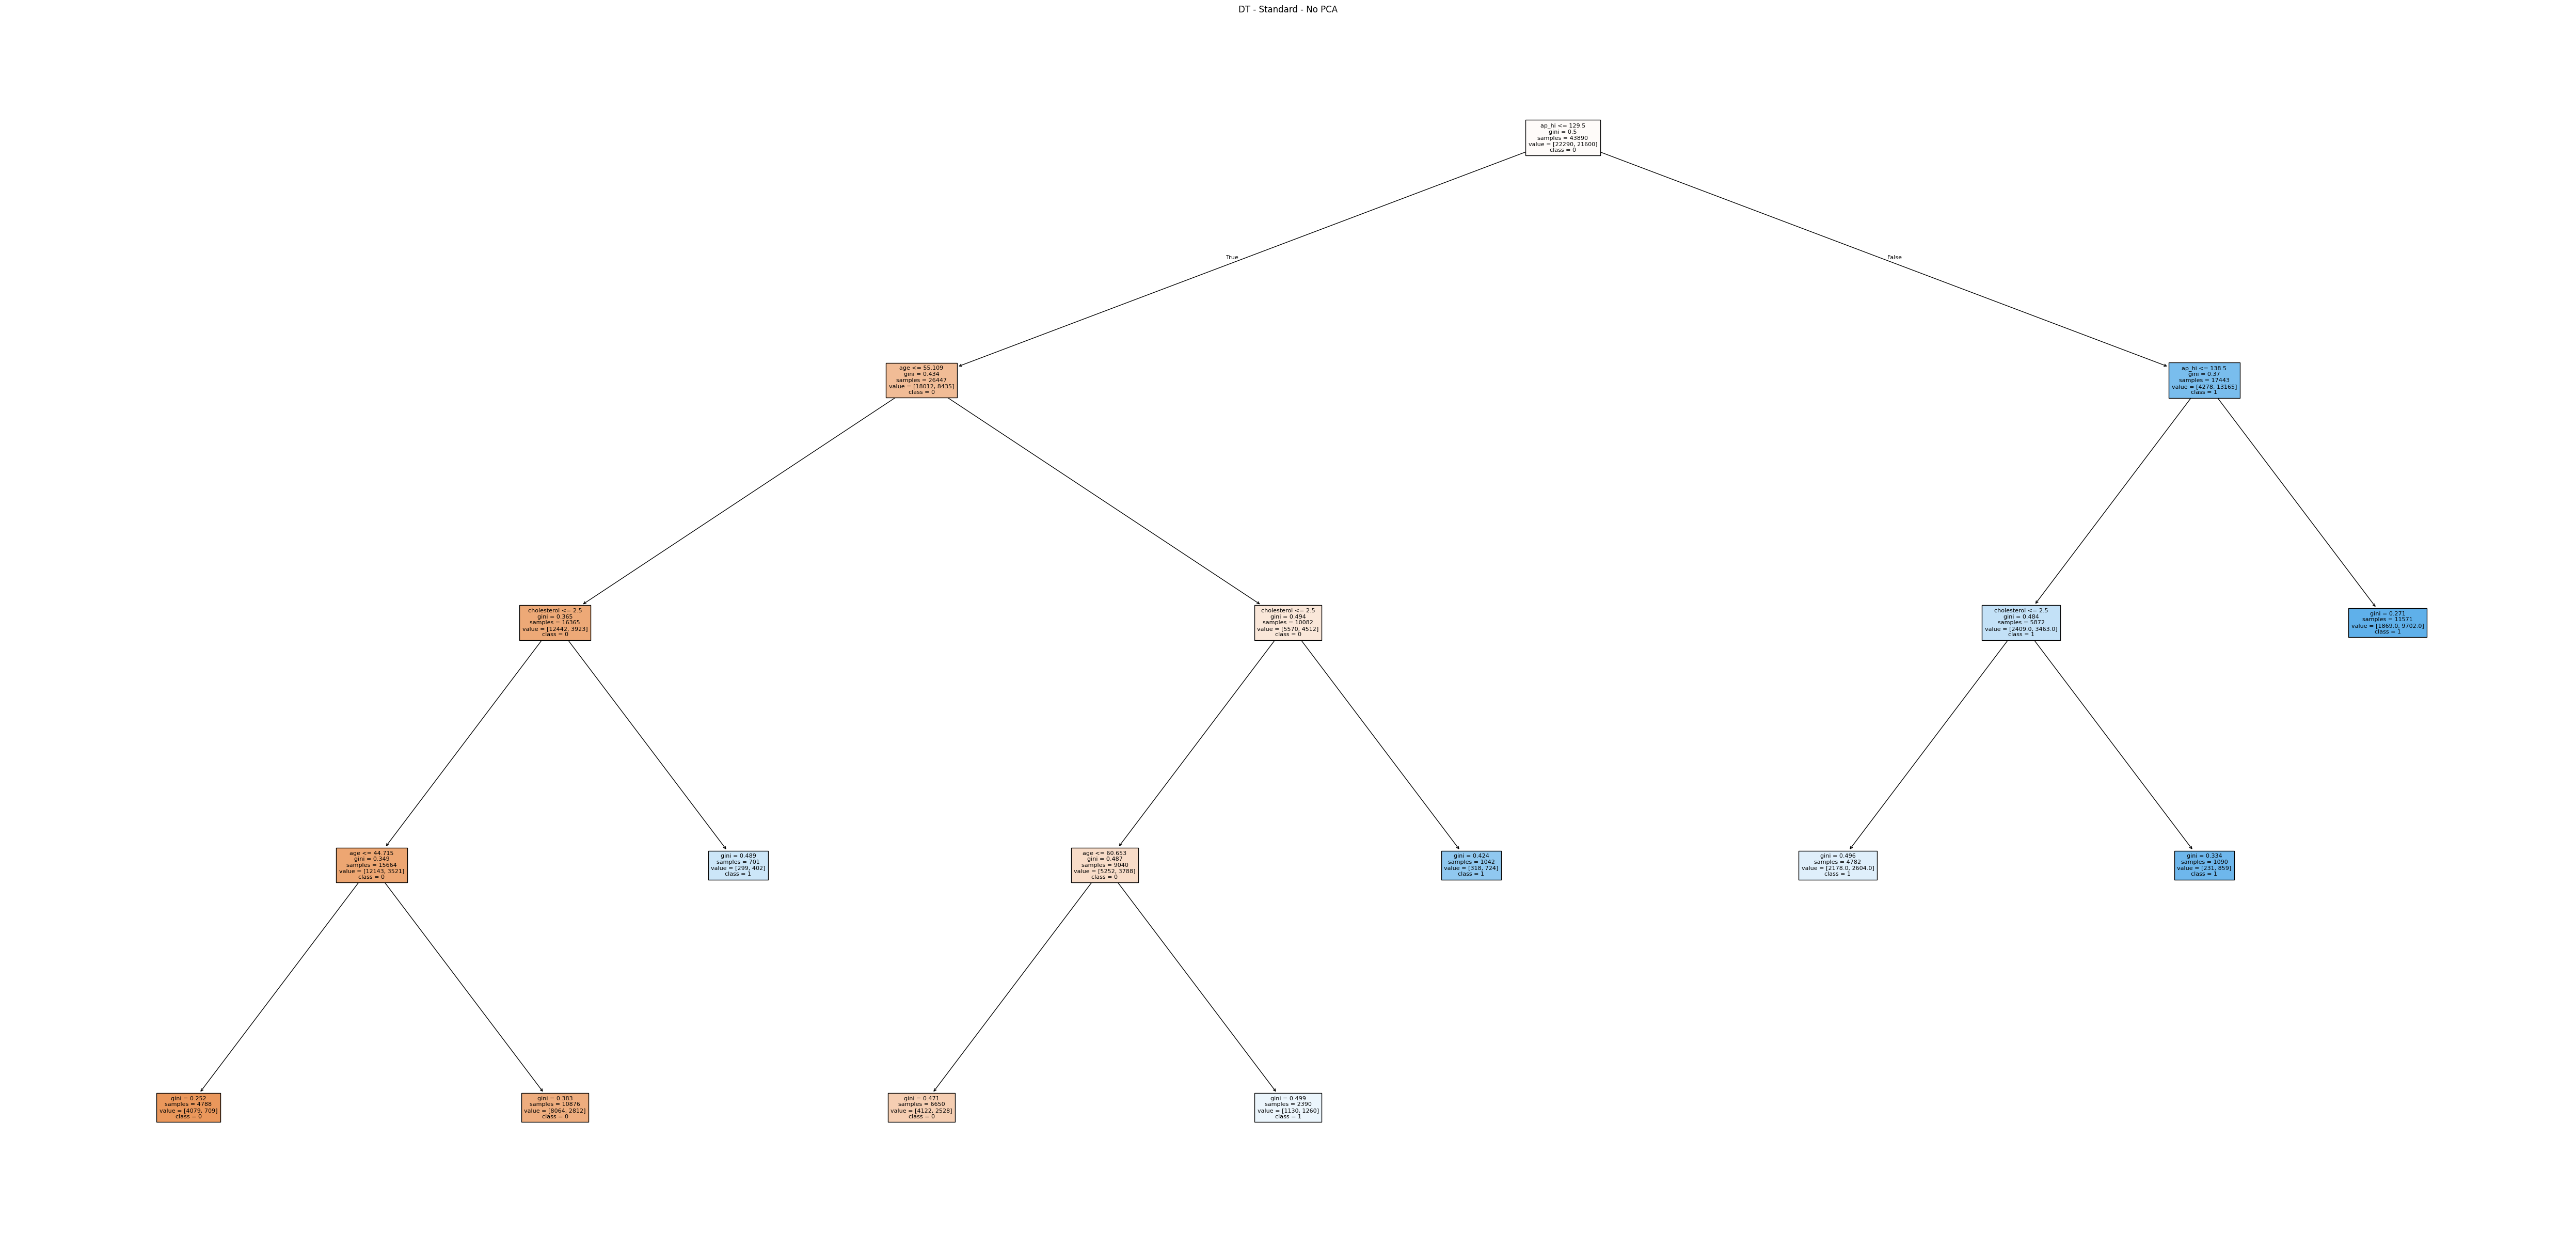

Accuracy: 0.7314
Profondità albero: 4
Numero di foglie: 9


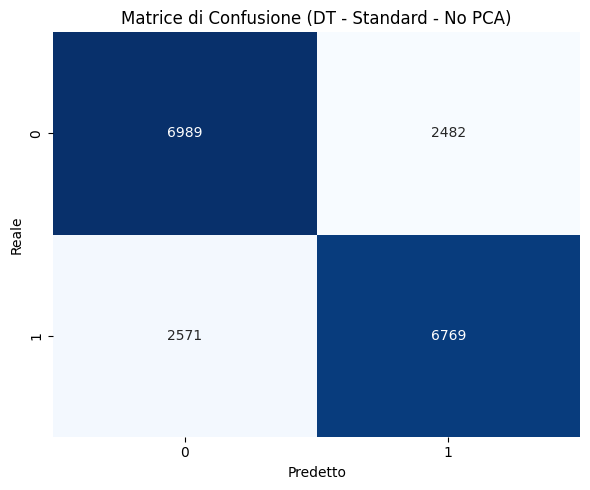


              precision    recall  f1-score   support

           0       0.73      0.74      0.73      9471
           1       0.73      0.72      0.73      9340

    accuracy                           0.73     18811
   macro avg       0.73      0.73      0.73     18811
weighted avg       0.73      0.73      0.73     18811



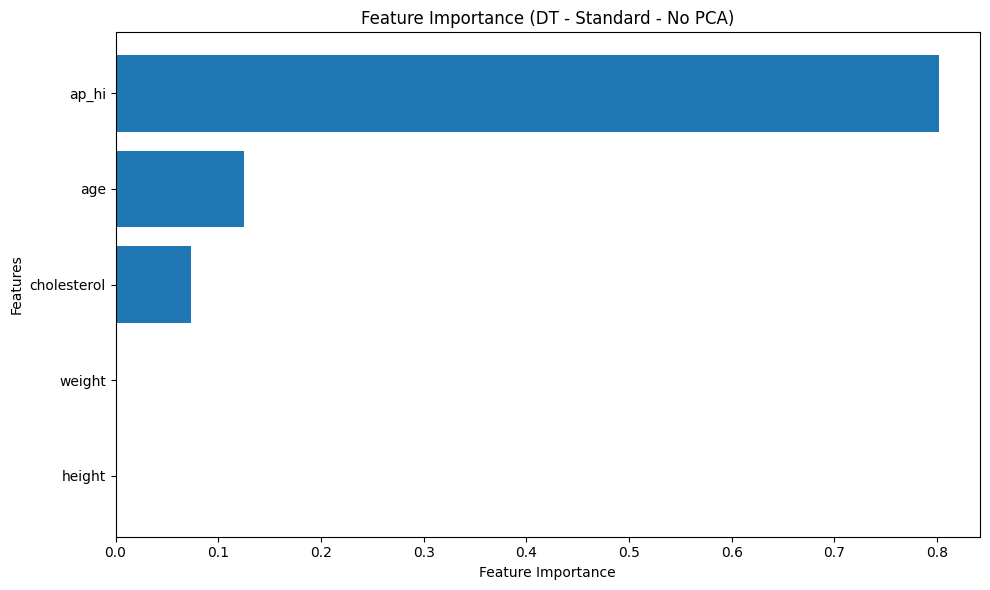


Feature Importance (DT - Standard - No PCA):
    feature  importance
      ap_hi    0.801725
        age    0.124709
cholesterol    0.073566
     weight    0.000000
     height    0.000000


In [140]:
# Visualizza albero
print_tree(
    dt_standard,
    max_depth=dt_standard.get_depth(),
    title="DT - Standard - No PCA",
    feature_names=all_features_dt,
)
show_tree_metrics(
    dt_standard, y_test_dt, y_pred_standard, title_suffix="DT - Standard - No PCA"
)
plot_feature_importance(
    dt_standard,
    feature_names=all_features_dt,
    title_suffix="DT - Standard - No PCA",
    top_n=5,
)

## Class Weight

Grid Search con class weights per gestire lo sbilanciamento delle classi.

In [141]:
# Grid Search con class_weight='balanced' sui dati NON SCALATI
dt_class_weights, grid_search_class_weights = run_grid_search(
    X_train_dt, y_train_dt, dt_param_grid, class_weight="balanced", scoring="f1"
)

y_pred_class_weights = dt_class_weights.predict(X_test_dt)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7201



### Risultati e Metriche

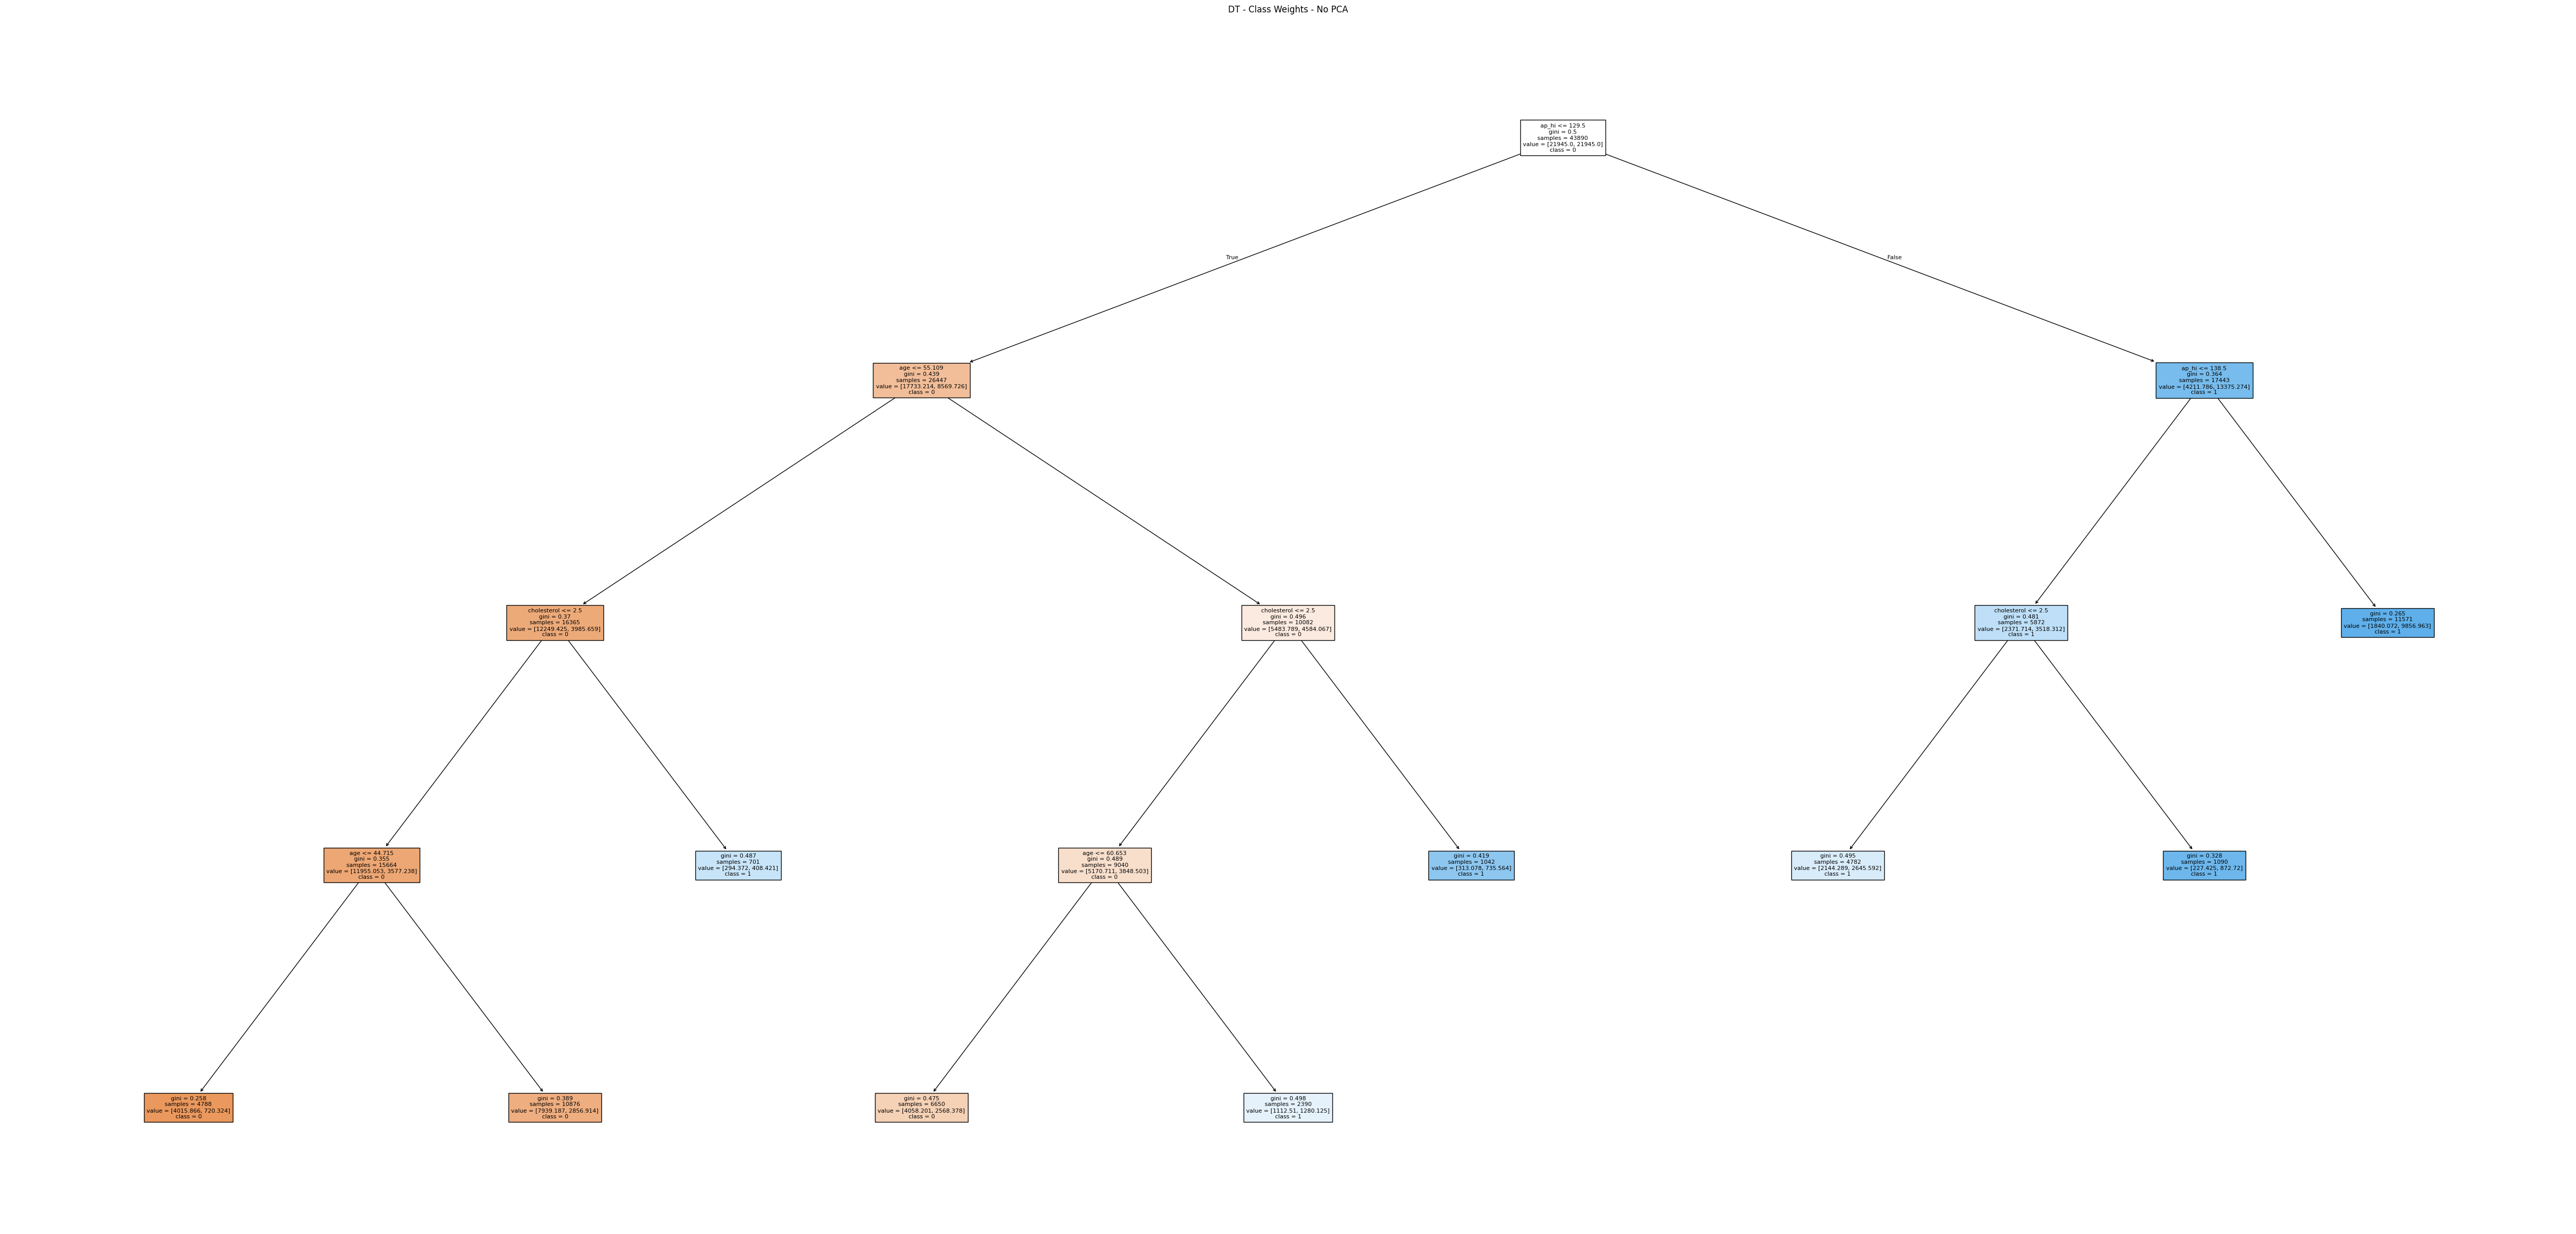

Accuracy: 0.7314
Profondità albero: 4
Numero di foglie: 9


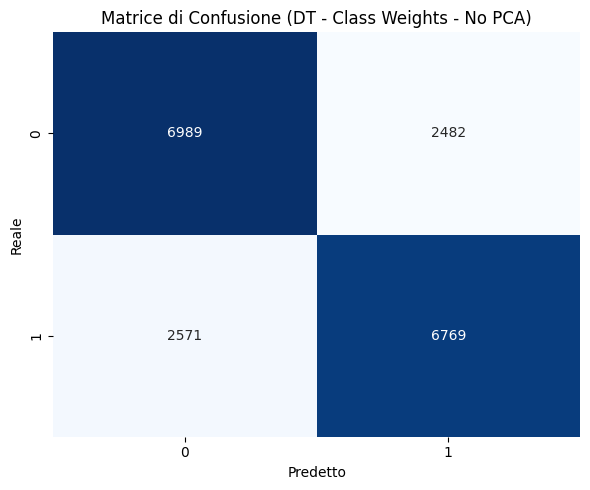


              precision    recall  f1-score   support

           0       0.73      0.74      0.73      9471
           1       0.73      0.72      0.73      9340

    accuracy                           0.73     18811
   macro avg       0.73      0.73      0.73     18811
weighted avg       0.73      0.73      0.73     18811



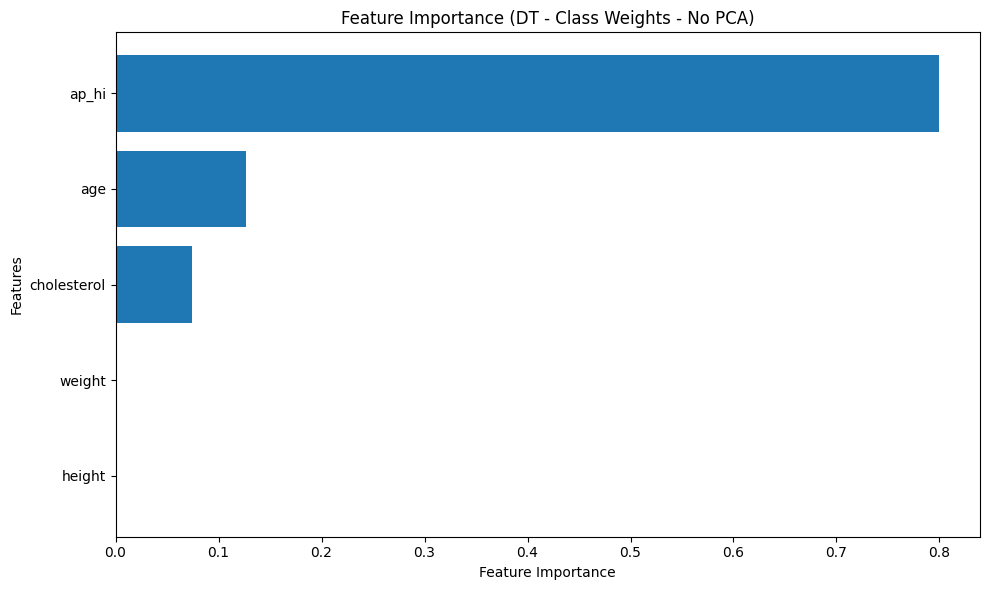


Feature Importance (DT - Class Weights - No PCA):
    feature  importance
      ap_hi    0.799367
        age    0.126849
cholesterol    0.073783
     weight    0.000000
     height    0.000000


In [142]:
# Visualizza albero con class weights
print_tree(
    dt_class_weights,
    dt_class_weights.get_depth(),
    "DT - Class Weights - No PCA",
    all_features_dt,
)
show_tree_metrics(
    dt_class_weights, y_test_dt, y_pred_class_weights, "DT - Class Weights - No PCA"
)

plot_feature_importance(
    dt_class_weights, all_features_dt, "DT - Class Weights - No PCA", top_n=5
)